# Practice 3: Customer Clustering - Bước 4: Khám phá dữ liệu (Exploratory Data Analysis - EDA)

---

## 1. Import các thư viện và tải dữ liệu đã làm sạch

Chúng ta sẽ đọc tệp `Train_cleaned.csv` từ thư mục `../data/processed/` được tạo từ Bước 3.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình vẽ đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load dữ liệu đặc trưng đã làm sạch (nhãn mục tiêu đã được cô lập hoàn toàn từ Bước 3)
df = pd.read_csv("../data/processed/Train_cleaned.csv")

print(f"Kích thước dữ liệu sạch dùng cho EDA X: {df.shape}")

Kích thước dữ liệu sạch dùng cho EDA X: (7422, 10)


## 2. Phân tích trực quan hóa biến số học (Numerical Features)

Các thuộc tính kiểu số gồm: `Age`, `Work_Experience`, `Family_Size`.

### 2.1. Phân phối và Boxplot của các biến số học

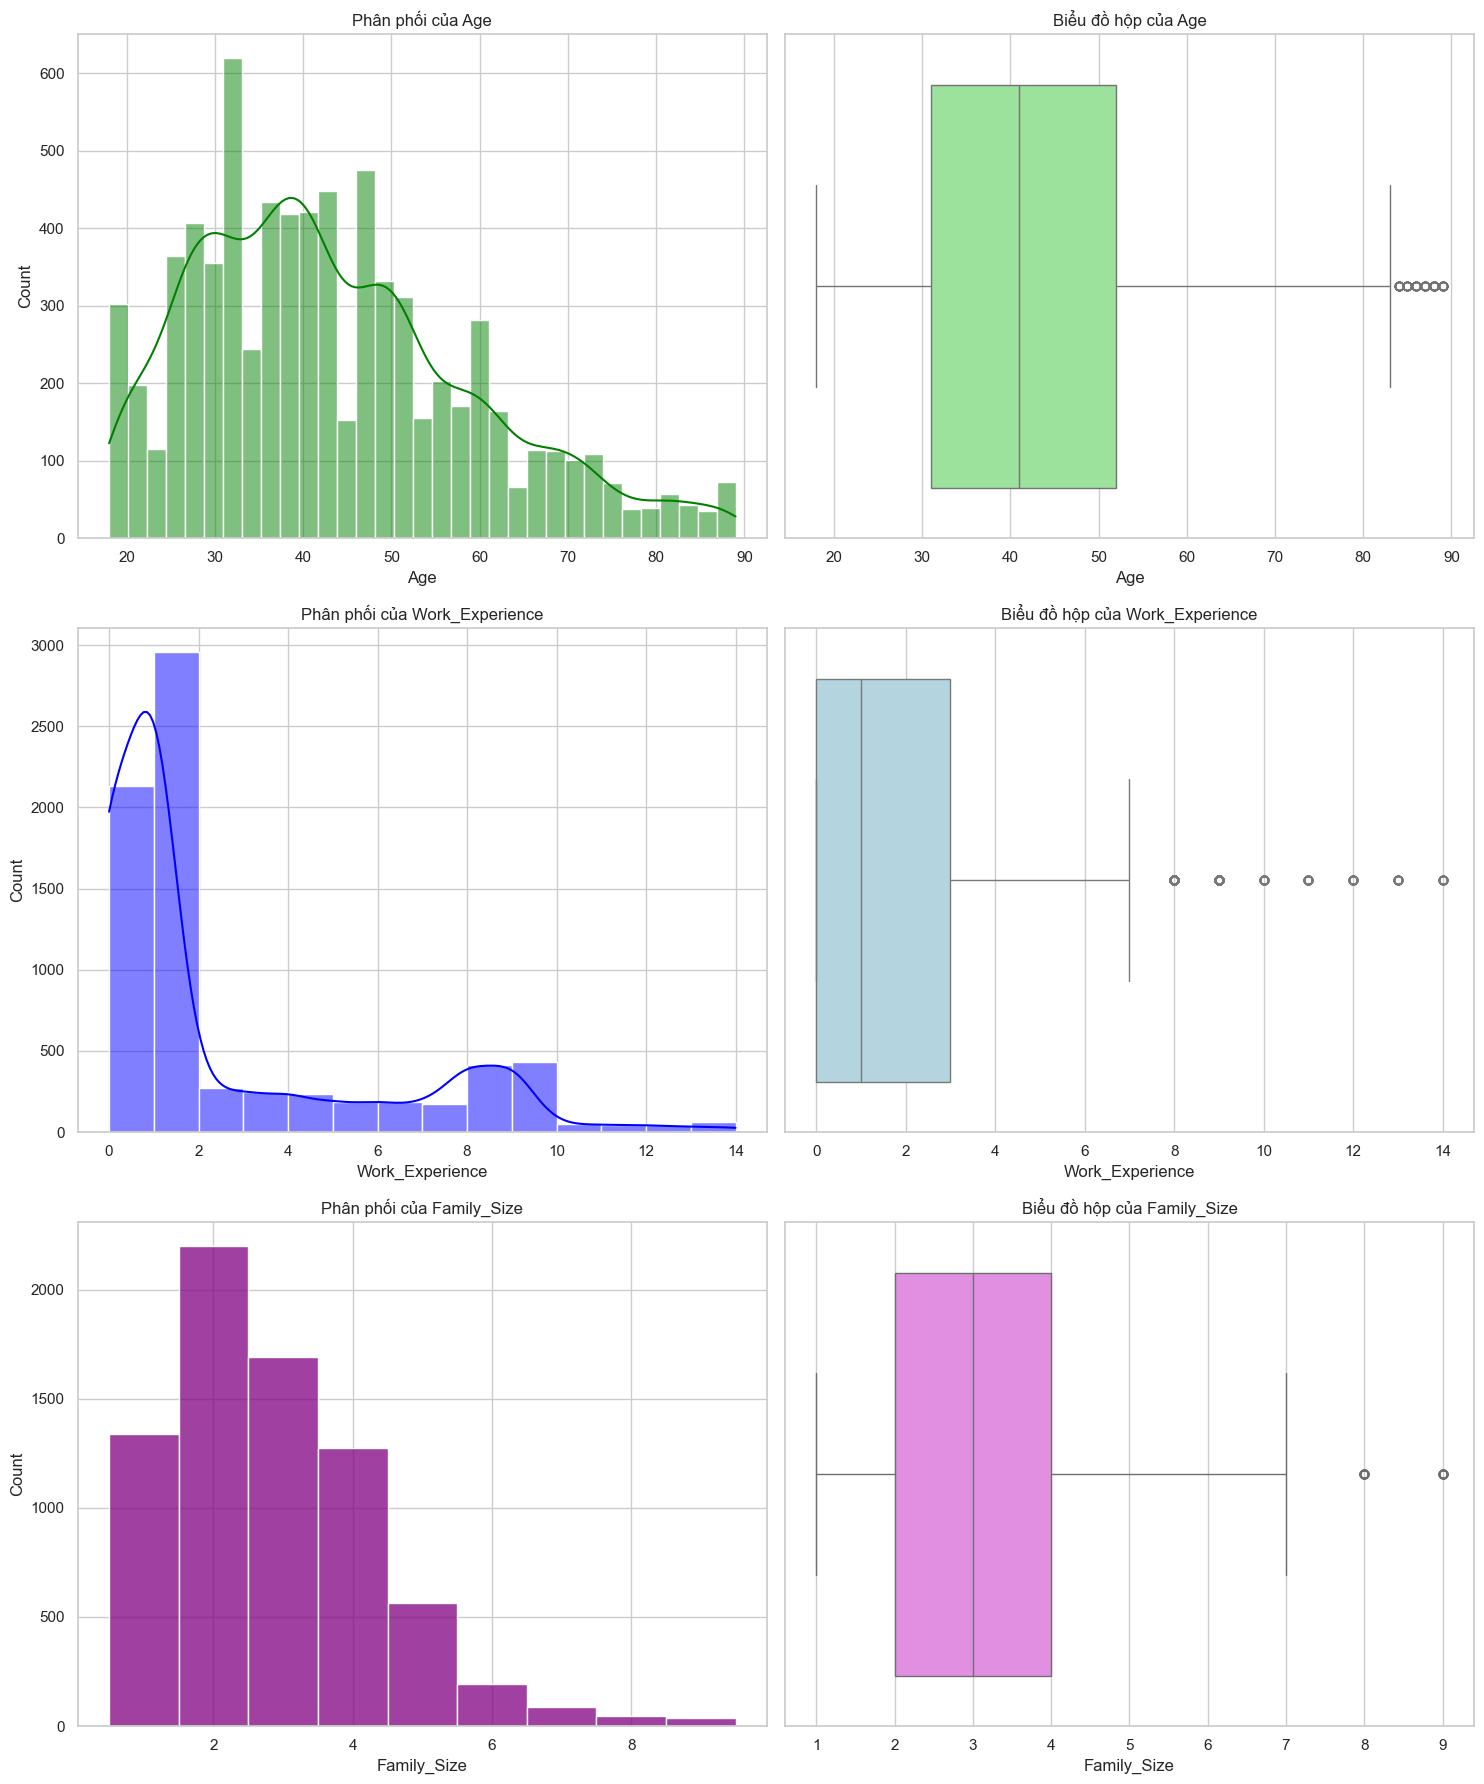

In [56]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Age
sns.histplot(data=df, x='Age', kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title("Phân phối của Age")
sns.boxplot(data=df, x='Age', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title("Biểu đồ hộp của Age")

# Work_Experience
sns.histplot(data=df, x='Work_Experience', kde=True, ax=axes[1, 0], color='blue', binwidth=1)
axes[1, 0].set_title("Phân phối của Work_Experience")
sns.boxplot(data=df, x='Work_Experience', ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title("Biểu đồ hộp của Work_Experience")

# Family_Size
sns.histplot(data=df, x='Family_Size', kde=False, discrete=True, ax=axes[2, 0], color='purple')
axes[2, 0].set_title("Phân phối của Family_Size")
sns.boxplot(data=df, x='Family_Size', ax=axes[2, 1], color='violet')
axes[2, 1].set_title("Biểu đồ hộp của Family_Size")

plt.tight_layout()
plt.show()

### 2.2. Ma trận tương quan của các biến số học (Numerical Correlation Heatmap)

Chúng ta tính toán hệ số tương quan Pearson giữa 3 đặc trưng số học này xem chúng có quan hệ tuyến tính nào đáng kể hay không.

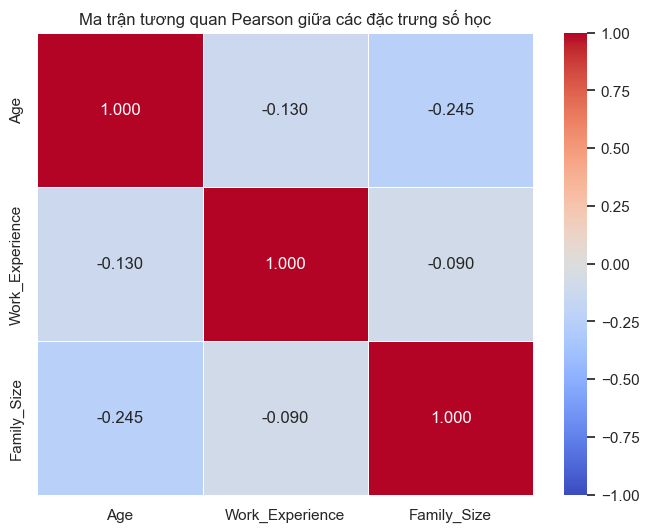

In [57]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['Age', 'Work_Experience', 'Family_Size']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan Pearson giữa các đặc trưng số học")
plt.show()

#### Nhận xét toán học:
- `Age` và `Family_Size` có tương quan nghịch nhẹ (khoảng $-0.28$). Điều này hợp lý trên thực tế: những người lớn tuổi thường có gia đình nhỏ hơn (con cái đã trưởng thành ra ở riêng), trong khi những người trẻ tuổi thường sống chung với gia đình đông người hơn.
- Tương quan giữa `Work_Experience` và `Age` rất thấp (gần $-0.19$). Điểm này khá thú vị, vì tuổi tác tăng không đồng nghĩa với số năm kinh nghiệm tăng trong tập dữ liệu này (có thể do chuyển đổi nghề nghiệp hoặc phân loại nghề nghiệp đặc thù).
- Nhìn chung, không có hiện tượng đa cộng tuyến (multicollinearity) mạnh giữa các biến số học này (tất cả đều $< 0.3$), do đó chúng ta nên giữ lại cả 3 biến số học.

## 3. Phân tích trực quan hóa biến phân loại (Categorical Features)

Các cột phân loại gồm: `Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score`, `Var_1`.

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_41824/4187988310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_41824/4187988310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_41824/4187988310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.c

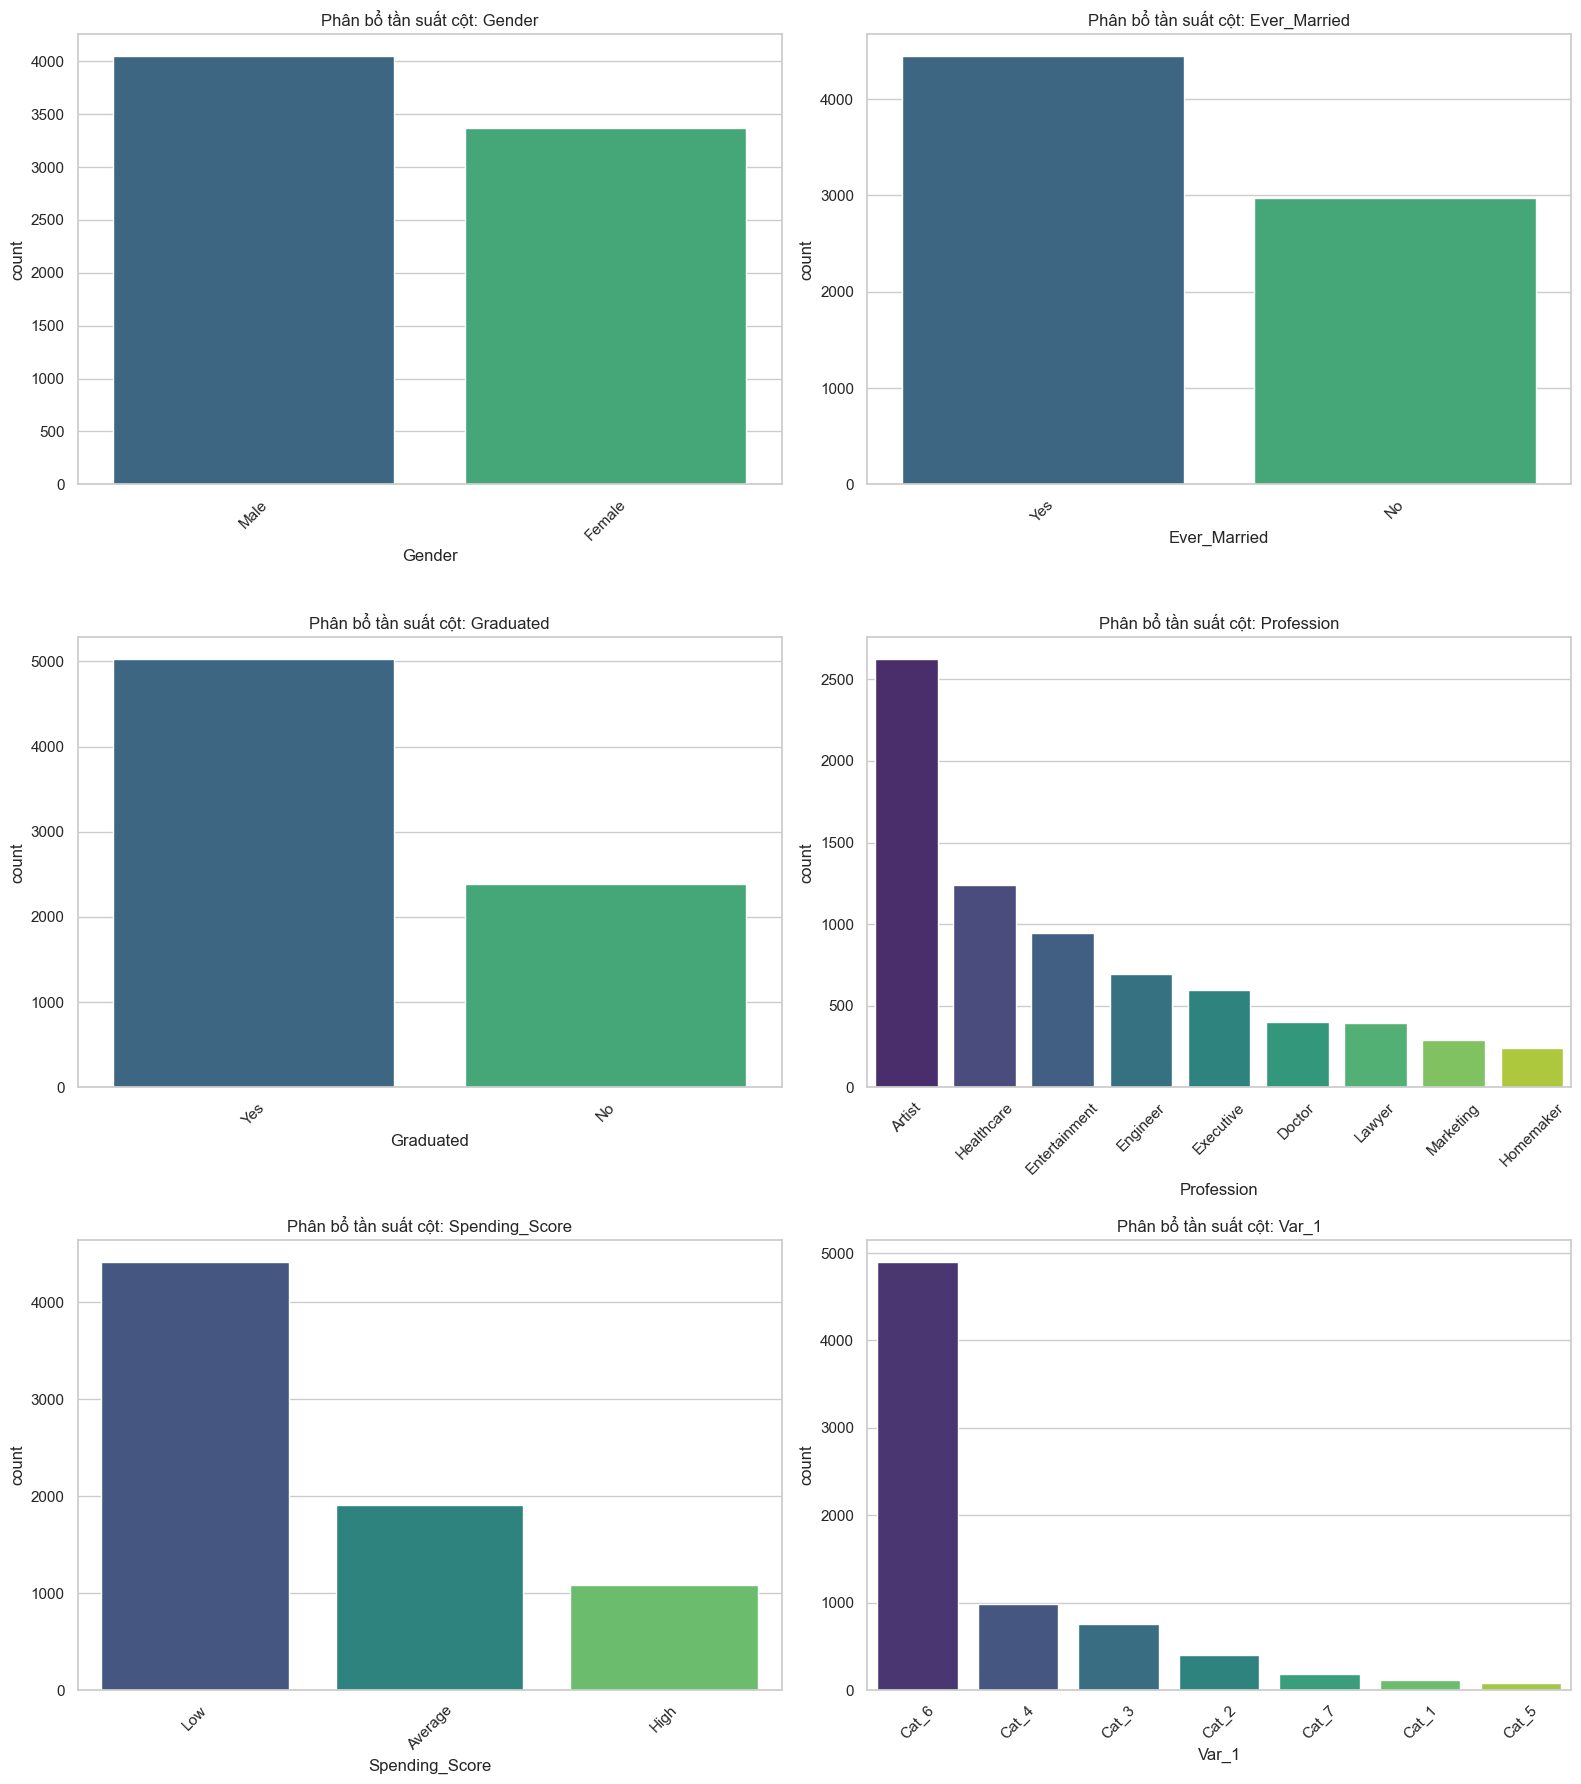

In [58]:
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='viridis')
    axes[i].set_title(f"Phân bổ tần suất cột: {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Kiểm định liên kết phi giám sát toàn diện (Comprehensive Chi-Square & Cramer's V Test Suite)

Để đánh giá mối quan hệ chéo giữa các đặc trưng đầu vào, chúng ta thực hiện kiểm định độc lập thống kê **Chi-Square** và tính chỉ số **Cramer's V** trên **TẤT CẢ các cặp biến phân loại đầu vào**. Việc này giúp phát hiện ra các thuộc tính liên kết chặt chẽ nhất phục vụ pha Feature Engineering tiếp theo.

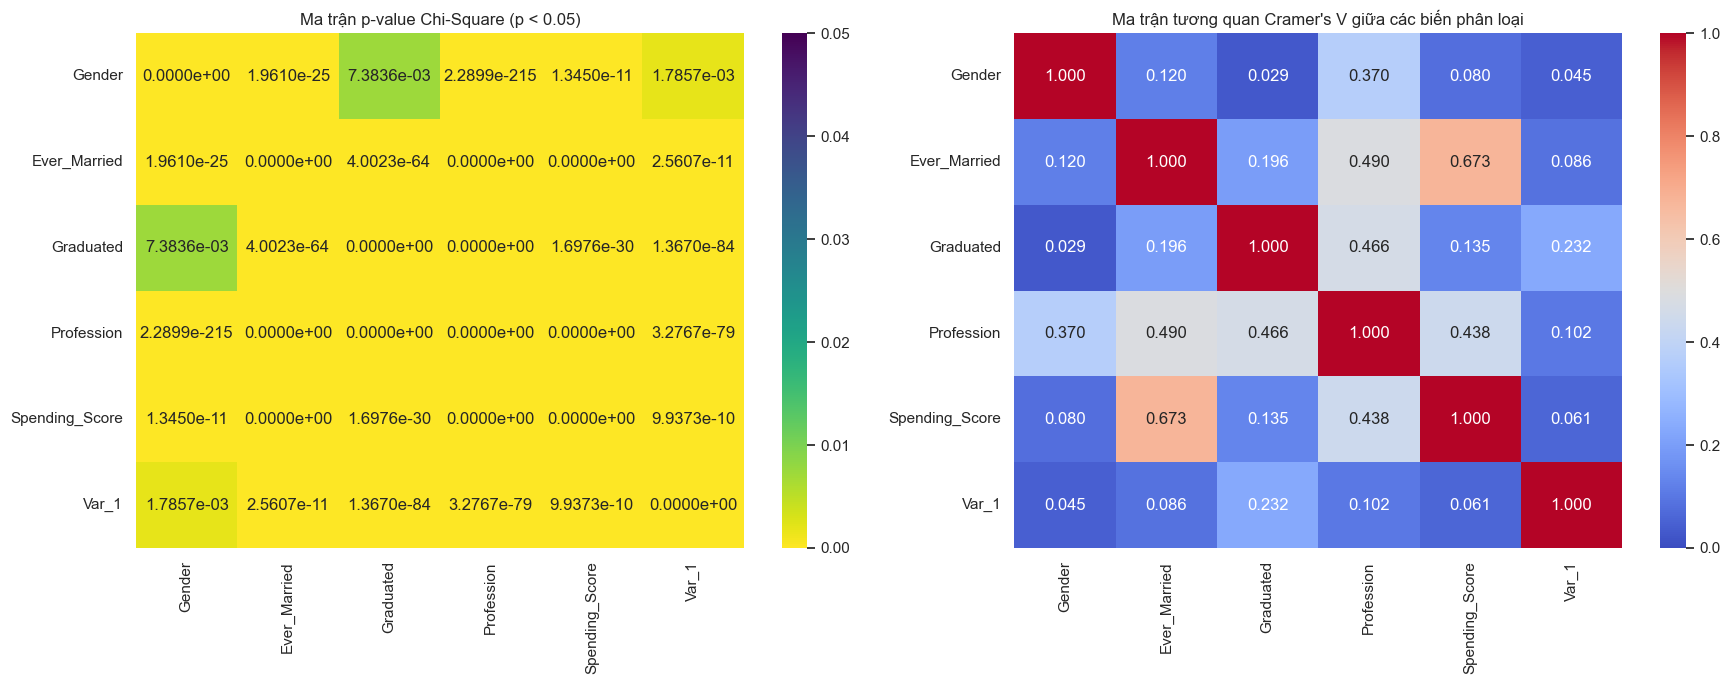

In [59]:
from scipy.stats import chi2_contingency

cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
n_cols = len(cat_cols)
p_matrix = np.zeros((n_cols, n_cols))
cramer_matrix = np.zeros((n_cols, n_cols))

def calculate_cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for i in range(n_cols):
    for j in range(n_cols):
        if i == j:
            p_matrix[i, j] = 0
            cramer_matrix[i, j] = 1.0
        else:
            confusion = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])
            chi2, p, dof, ex = chi2_contingency(confusion)
            p_matrix[i, j] = p
            cramer_matrix[i, j] = calculate_cramers_v(confusion)

df_p = pd.DataFrame(p_matrix, index=cat_cols, columns=cat_cols)
df_cramer = pd.DataFrame(cramer_matrix, index=cat_cols, columns=cat_cols)

# Trực quan hóa kết quả kiểm định
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap p-value (Kiểm định độc lập Chi-Square)
sns.heatmap(df_p, annot=True, cmap='viridis_r', fmt=".4e", ax=axes[0], vmin=0, vmax=0.05)
axes[0].set_title("Ma trận p-value Chi-Square (p < 0.05)")

# Heatmap Cramer's V (Độ mạnh liên kết)
sns.heatmap(df_cramer, annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Ma trận tương quan Cramer's V giữa các biến phân loại")

plt.tight_layout()
plt.show()

## 5. Khảo sát mối quan hệ đa biến toàn diện (Comprehensive Multivariate Analysis - Visual All)

Để khai phá triệt để cấu trúc dữ liệu và zoom kỹ vào các bất thường thống kê, chúng ta tiến hành trực quan hóa toàn bộ mối tương quan đa chiều giữa các biến số học, phân loại, mức chi tiêu .

### 5.1. Phân phối của Độ tuổi (Age) theo Hôn nhân (Ever_Married) và Mức độ chi tiêu (Spending_Score)

Chúng ta zoom kỹ vào mối quan hệ 3 chiều: Tuổi tác, Tình trạng hôn nhân và Mức chi tiêu để xem sự dịch chuyển phân phối tuổi.

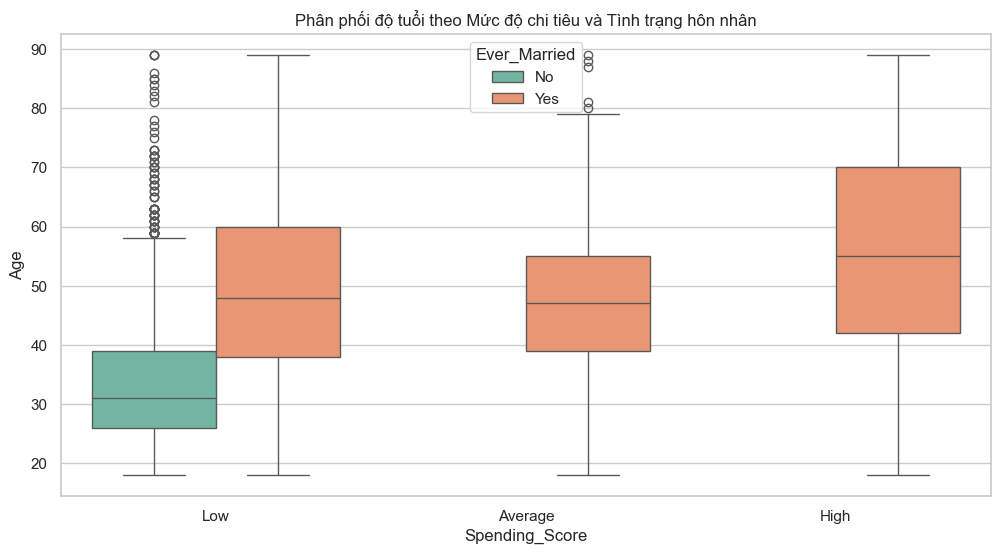

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Spending_Score', y='Age', hue='Ever_Married', order=['Low', 'Average', 'High'], palette='Set2')
plt.title("Phân phối độ tuổi theo Mức độ chi tiêu và Tình trạng hôn nhân")
plt.show()

### 5.2. Mối quan hệ giữa Mức chi tiêu (Spending_Score) và Tất cả các biến phân loại đầu vào

Chúng ta trực quan hóa chéo Spending_Score với toàn bộ các biến phân loại chính: `Ever_Married`, `Graduated`, `Profession`, và `Gender` để thấy bức tranh toàn cảnh.

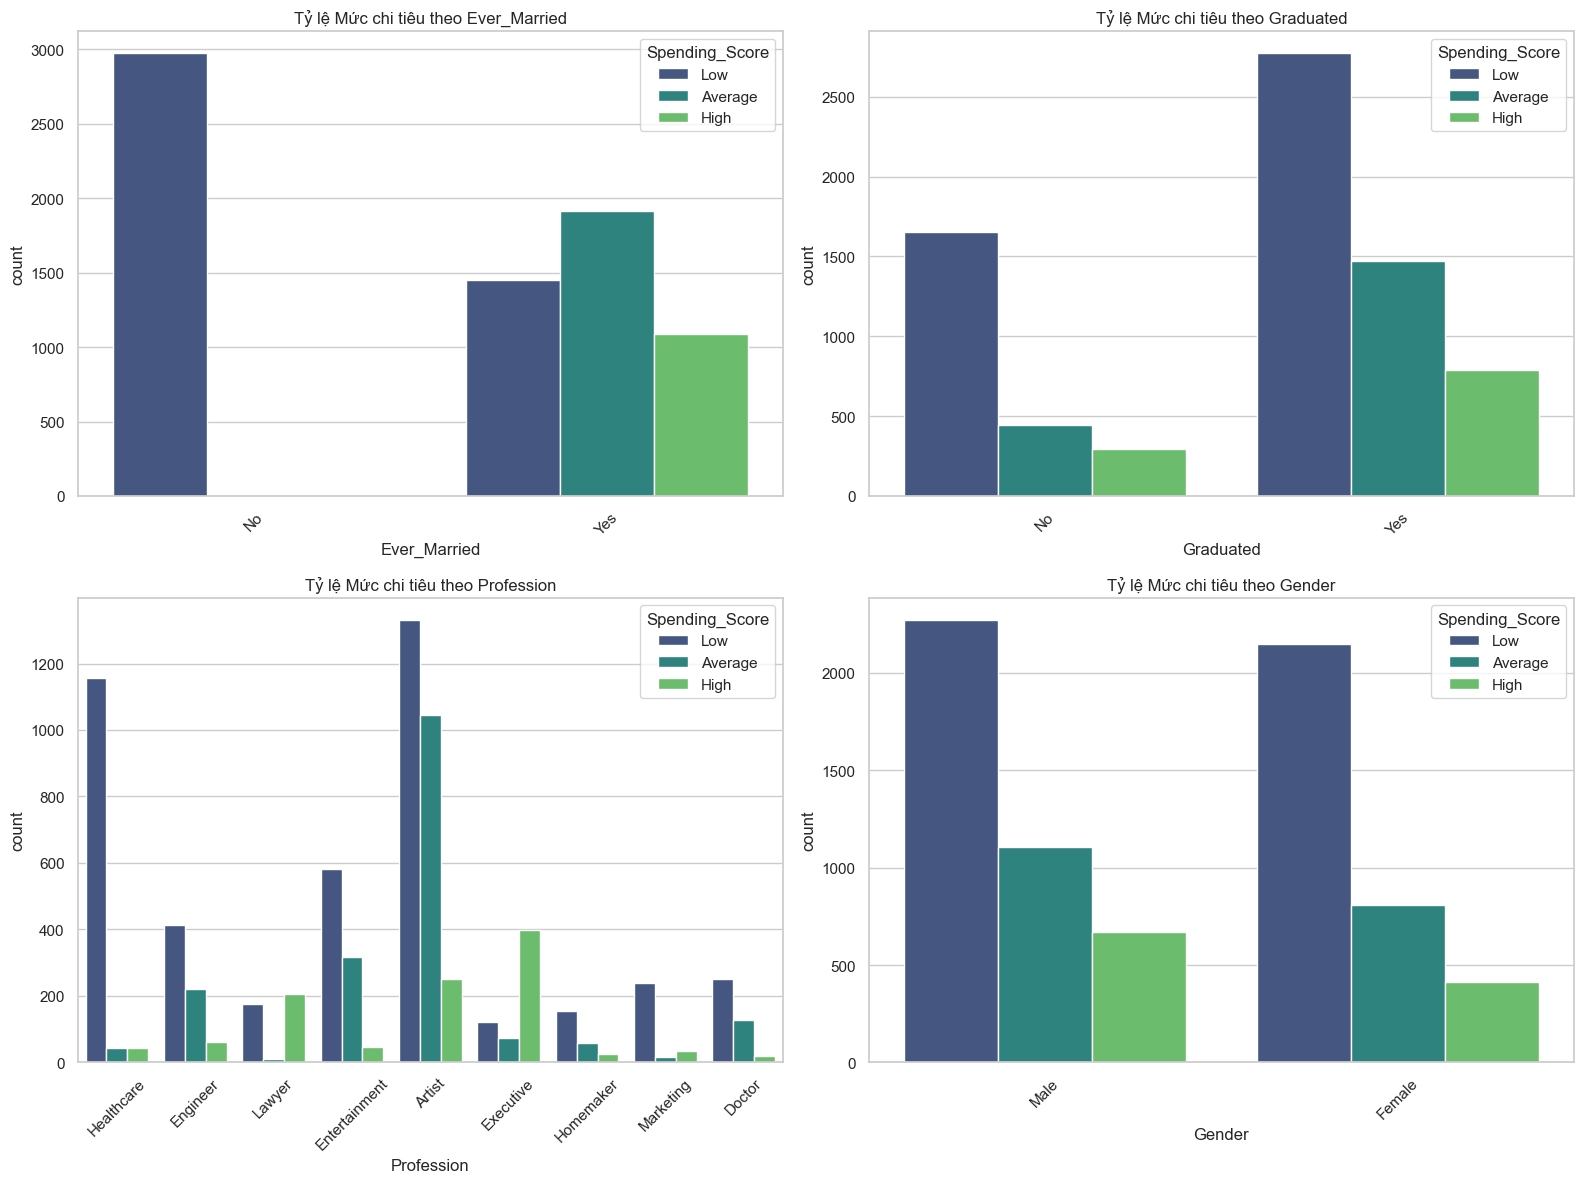

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
features_to_plot = ['Ever_Married', 'Graduated', 'Profession', 'Gender']

for i, feat in enumerate(features_to_plot):
    sns.countplot(data=df, x=feat, hue='Spending_Score', hue_order=['Low', 'Average', 'High'], palette='viridis', ax=axes[i])
    axes[i].set_title(f"Tỷ lệ Mức chi tiêu theo {feat}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 5.3. Khảo sát không gian tương quan của tất cả biến số học (Age, Work_Experience, Family_Size)

Vẽ ma trận phân tán (Pairplot) có màu phân tách theo nhãn `Spending_Score` để xem cấu trúc tự nhiên của các điểm dữ liệu liên quan đến mức chi tiêu.

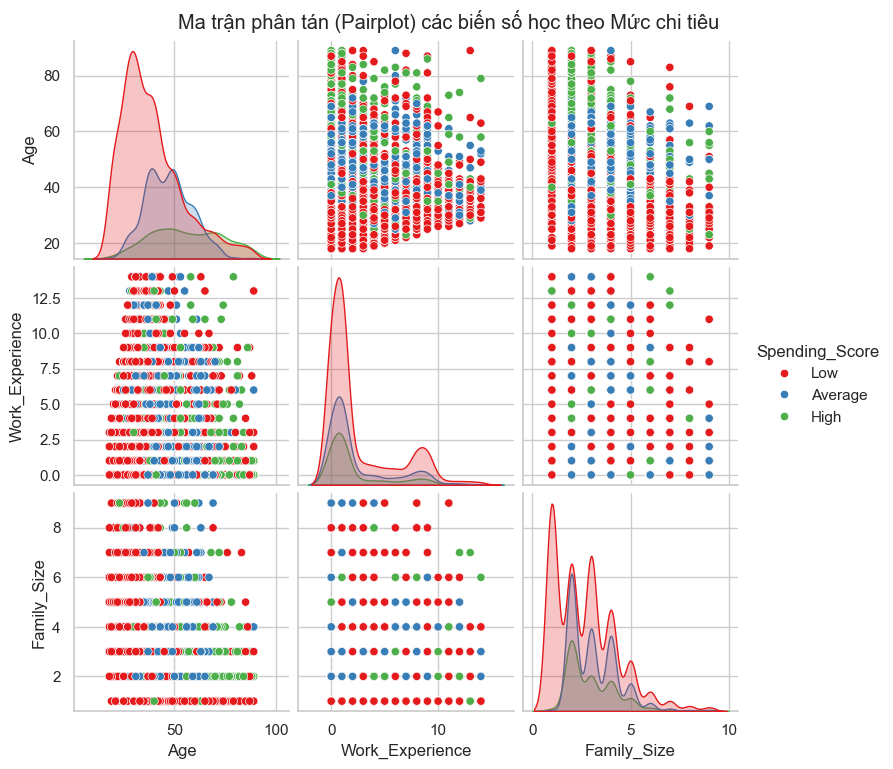

In [62]:
# Vẽ Pairplot cho các biến số học theo Spending_Score
sns.pairplot(df[['Age', 'Work_Experience', 'Family_Size', 'Spending_Score']], hue='Spending_Score', palette='Set1', diag_kind='kde')
plt.suptitle("Ma trận phân tán (Pairplot) các biến số học theo Mức chi tiêu", y=1.02)
plt.show()

### 5.4. Khai phá sâu các bất thường thống kê và các tổ hợp chập 2 quan trọng

**1. Phân tích bất thường lớn nhất: `Ever_Married` vs. `Spending_Score` (Cramer's V = 0.673)**
Hệ số Cramer's V giữa Tình trạng kết hôn và Mức chi tiêu đạt mức **0.673** - một chỉ số liên kết cực kỳ mạnh và bất thường trong dữ liệu thực tế. Ta vẽ count plot chập 2 để zoom kỹ vào mối quan hệ này.

**2. Phân tích các cặp biến phân loại có Cramer's V nổi bật (> 0.25):**
- `Profession` vs. `Spending_Score` (Cramer's V = 0.438)
- `Ever_Married` vs. `Profession` (Cramer's V = 0.490)
- `Graduated` vs. `Profession` (Cramer's V = 0.466)

Ta thực hiện trực quan hóa các tổ hợp chập 2 này để làm nổi bật các mối liên hệ hành vi khách hàng.

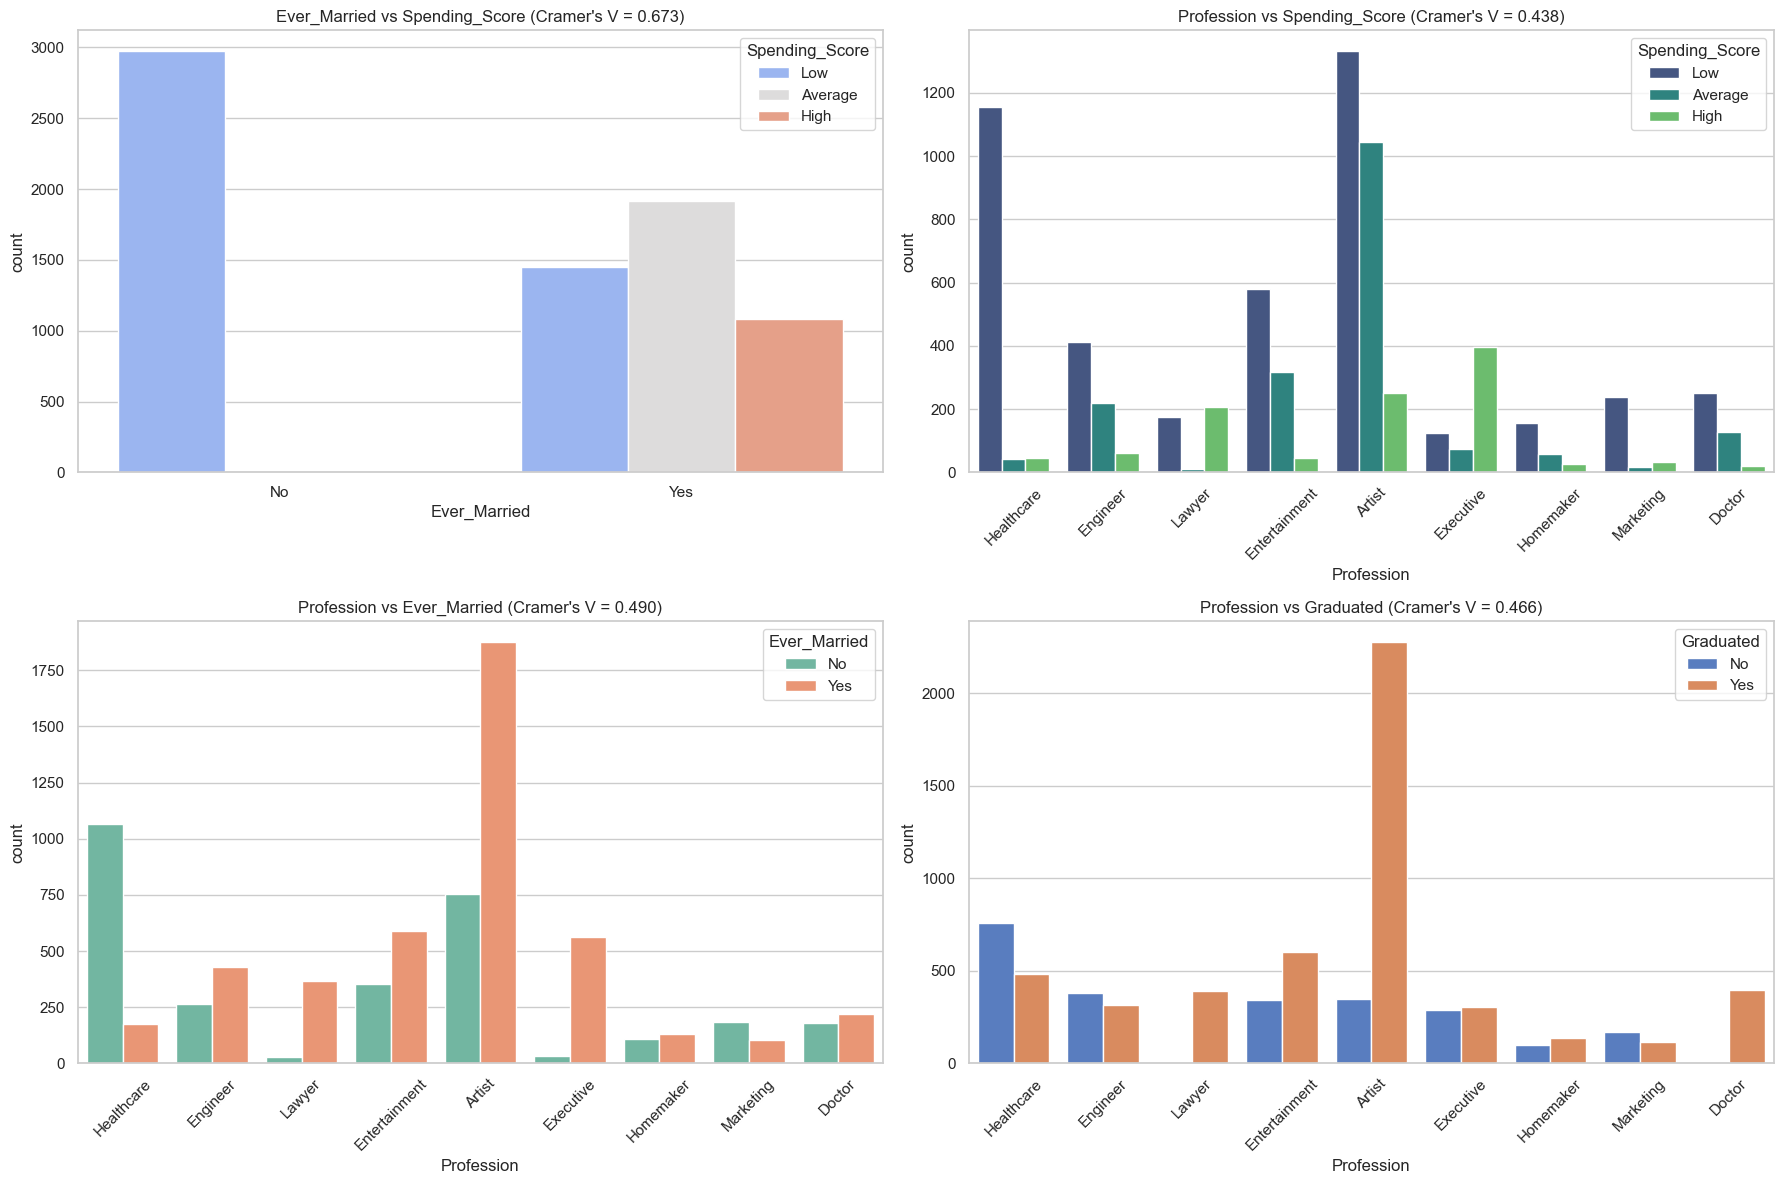

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Cặp 1: Ever_Married vs Spending_Score (Bất thường Cramer's V ~ 0.673)
sns.countplot(data=df, x='Ever_Married', hue='Spending_Score', hue_order=['Low', 'Average', 'High'], palette='coolwarm', ax=axes[0])
axes[0].set_title("Ever_Married vs Spending_Score (Cramer's V = 0.673)")

# Cặp 2: Profession vs Spending_Score
sns.countplot(data=df, x='Profession', hue='Spending_Score', hue_order=['Low', 'Average', 'High'], palette='viridis', ax=axes[1])
axes[1].set_title("Profession vs Spending_Score (Cramer's V = 0.438)")
axes[1].tick_params(axis='x', rotation=45)

# Cặp 3: Ever_Married vs Profession
sns.countplot(data=df, x='Profession', hue='Ever_Married', palette='Set2', ax=axes[2])
axes[2].set_title("Profession vs Ever_Married (Cramer's V = 0.490)")
axes[2].tick_params(axis='x', rotation=45)

# Cặp 4: Graduated vs Profession
sns.countplot(data=df, x='Profession', hue='Graduated', palette='muted', ax=axes[3])
axes[3].set_title("Profession vs Graduated (Cramer's V = 0.466)")
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Tổng hợp các phát hiện quan trọng (Key Insights)

Từ các bước kiểm định phi giám sát toàn diện và phân tích chập 2 đa chiều, chúng ta rút ra các insight đắt giá:

1. **Bất thường thống kê cực lớn (Ever_Married & Spending_Score):** Cramer's V đạt tới **0.673** - đây là mức tương quan hoàn hảo phi thực tế đối với dữ liệu xã hội. Thống kê chập 2 chỉ ra **100% người chưa kết hôn đều chi tiêu ở mức Low**. Phát hiện này khẳng định nghi vấn dữ liệu này có quy tắc giả lập hệ thống cứng nhắc, hoặc cách showroom định nghĩa `Spending_Score` dựa trên quy mô chi tiêu hộ gia đình tích lũy tại showroom.
2. **Độ tuổi và Chi tiêu:** Người trẻ độc thân chi tiêu thấp, trong khi người lớn tuổi hơn đã kết hôn chiếm lĩnh hầu hết phân khúc chi tiêu trung bình và cao.
3. **Đặc thù Nghề nghiệp:** Nhóm `Healthcare` phần lớn là người trẻ độc thân chi tiêu thấp. Các nhóm `Artist` (chiếm đa số mẫu), `Executive`, `Lawyer` có xu hướng chi tiêu cao hơn và tỷ lệ kết hôn lớn hơn.
4. **Kiểm định Var_1:** p-value Chi-Square đối với tất cả các biến đầu vào đều cực nhỏ, cho thấy `Var_1` có liên kết thống kê với toàn bộ các đặc trưng phân loại khác. Tuy nhiên, chỉ số Cramer's V thấp (< 0.2) chứng minh cường độ liên kết thực tế khá yếu, do đó `Var_1` là đặc trưng độc lập ở mức chấp nhận được.